# Round 2 — Data Visualization\n\nProducts: **INTARIAN_PEPPER_ROOT** and **ASH_COATED_OSMIUM** across Days -1, 0, 1.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

DATA_PATH = "/Users/sakshamagarwal/Desktop/Prosperity/ROUND2/Wiki_ROUND_2_data/"
DAYS = [-1, 0, 1]
PRODUCTS = ["INTARIAN_PEPPER_ROOT", "ASH_COATED_OSMIUM"]
COLORS = {"INTARIAN_PEPPER_ROOT": "#e67e22", "ASH_COATED_OSMIUM": "#2980b9"}
DAY_COLORS = {-1: "#c0392b", 0: "#27ae60", 1: "#8e44ad"}

price_frames, trade_frames = [], []
for day in DAYS:
    p = pd.read_csv(f"{DATA_PATH}prices_round_2_day_{day}.csv", sep=";")
    t = pd.read_csv(f"{DATA_PATH}trades_round_2_day_{day}.csv", sep=";")
    p["day"] = day
    t["day"] = day
    price_frames.append(p)
    trade_frames.append(t)

prices = pd.concat(price_frames, ignore_index=True)
trades = pd.concat(trade_frames, ignore_index=True)
prices["spread"] = prices["ask_price_1"] - prices["bid_price_1"]

def get_prices(product, day=None):
    mask = prices["product"] == product
    if day is not None:
        mask &= prices["day"] == day
    return prices[mask].sort_values("timestamp")

def get_trades(product, day=None):
    mask = trades["symbol"] == product
    if day is not None:
        mask &= trades["day"] == day
    return trades[mask].sort_values("timestamp")

print("Loaded:", prices.shape, "price rows |", trades.shape, "trade rows")
print("Products:", prices["product"].unique())

Loaded: (60000, 18) price rows | (2391, 8) trade rows
Products: <StringArray>
['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']
Length: 2, dtype: str


## Fig 1 — Mid-Price per Day (with 500-tick moving average)

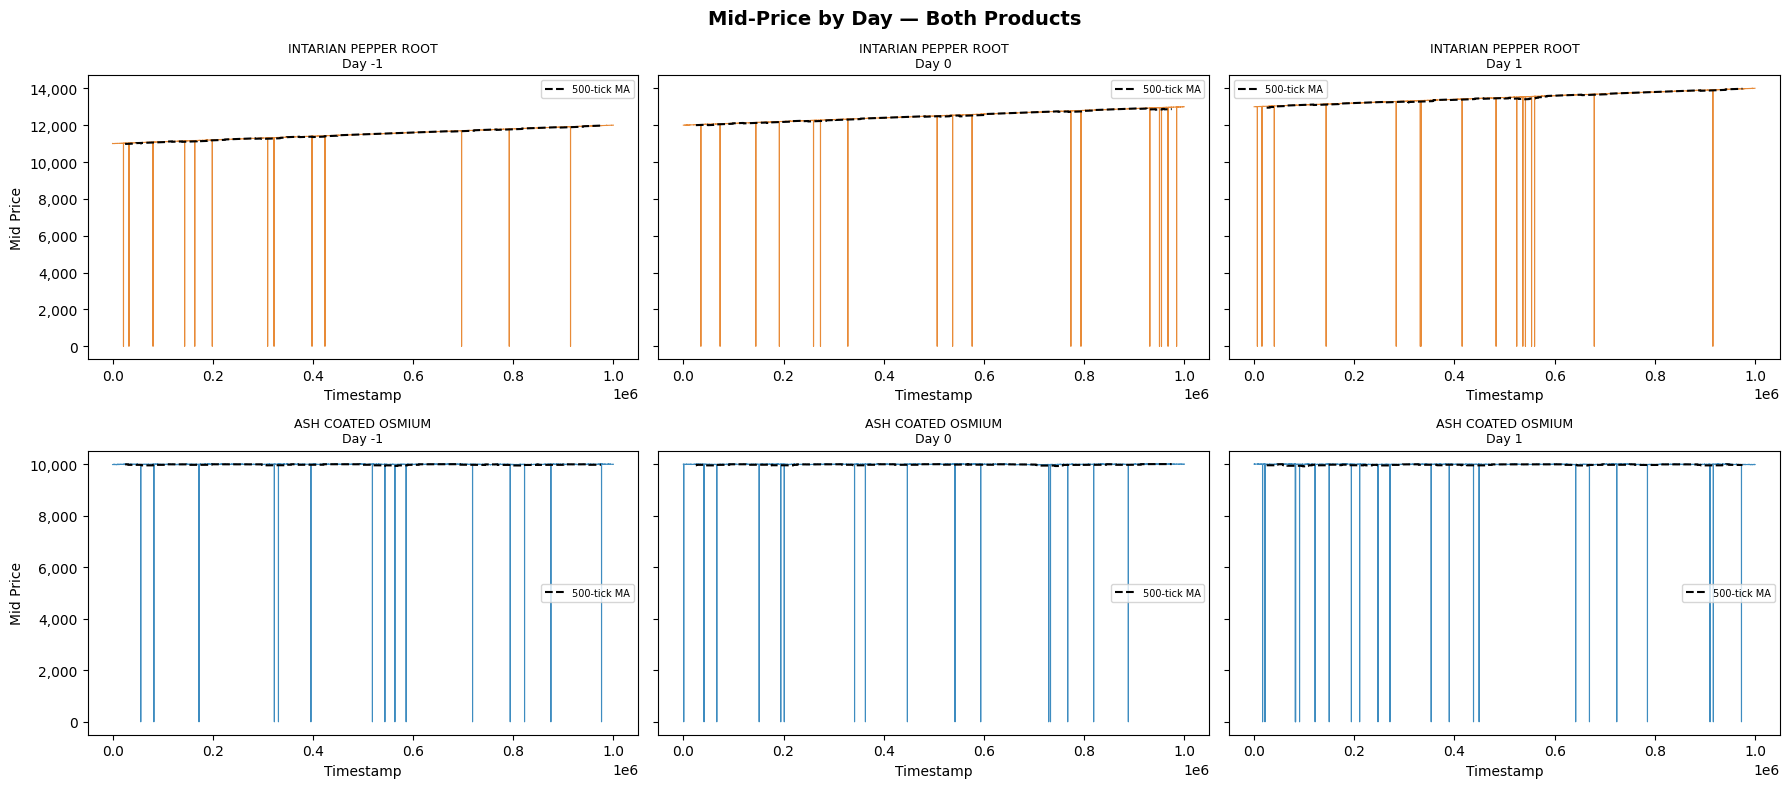

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey="row")
fig.suptitle("Mid-Price by Day — Both Products", fontsize=14, fontweight="bold")

for row, prod in enumerate(PRODUCTS):
    for col, day in enumerate(DAYS):
        ax = axes[row][col]
        sub = get_prices(prod, day)
        ax.plot(sub["timestamp"], sub["mid_price"], color=COLORS[prod], linewidth=0.8, alpha=0.9)
        rolling = sub["mid_price"].rolling(500, center=True).mean()
        ax.plot(sub["timestamp"], rolling, color="black", linewidth=1.5, linestyle="--", label="500-tick MA")
        ax.set_title(f"{prod.replace('_', ' ')}\nDay {day}", fontsize=9)
        ax.set_xlabel("Timestamp")
        if col == 0:
            ax.set_ylabel("Mid Price")
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## Fig 2 — Bid-Ask Spread Distribution

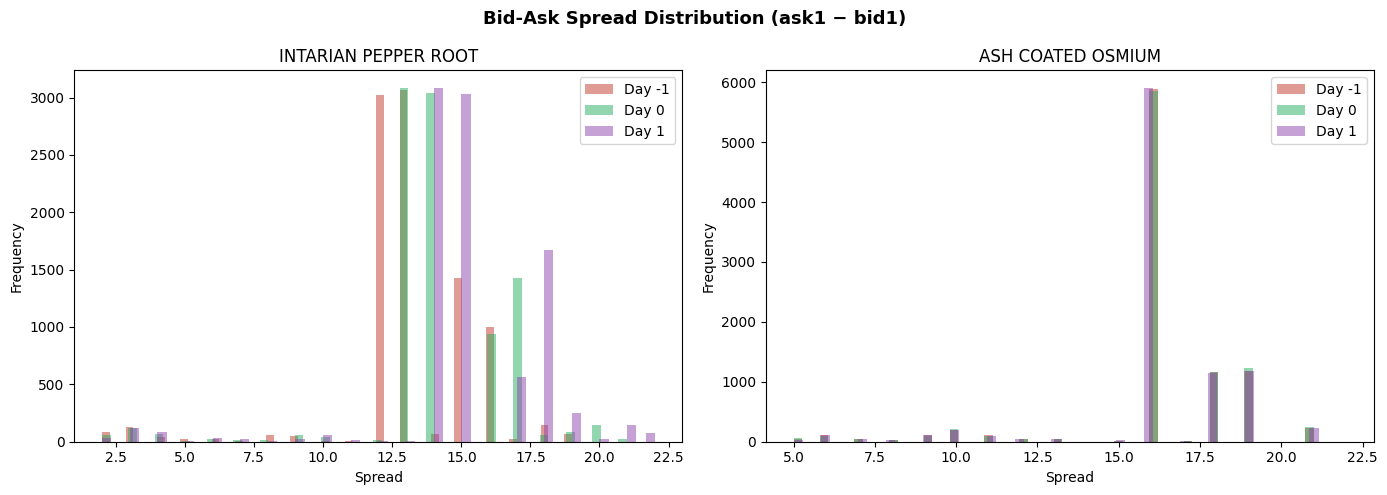

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Bid-Ask Spread Distribution (ask1 − bid1)", fontsize=13, fontweight="bold")

for ax, prod in zip(axes, PRODUCTS):
    for day in DAYS:
        sub = get_prices(prod, day)
        ax.hist(sub["spread"].dropna(), bins=60, alpha=0.5, label=f"Day {day}", color=DAY_COLORS[day])
    ax.set_title(prod.replace("_", " "))
    ax.set_xlabel("Spread")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.show()

## Fig 3 — Trade Prices & Volume per Day

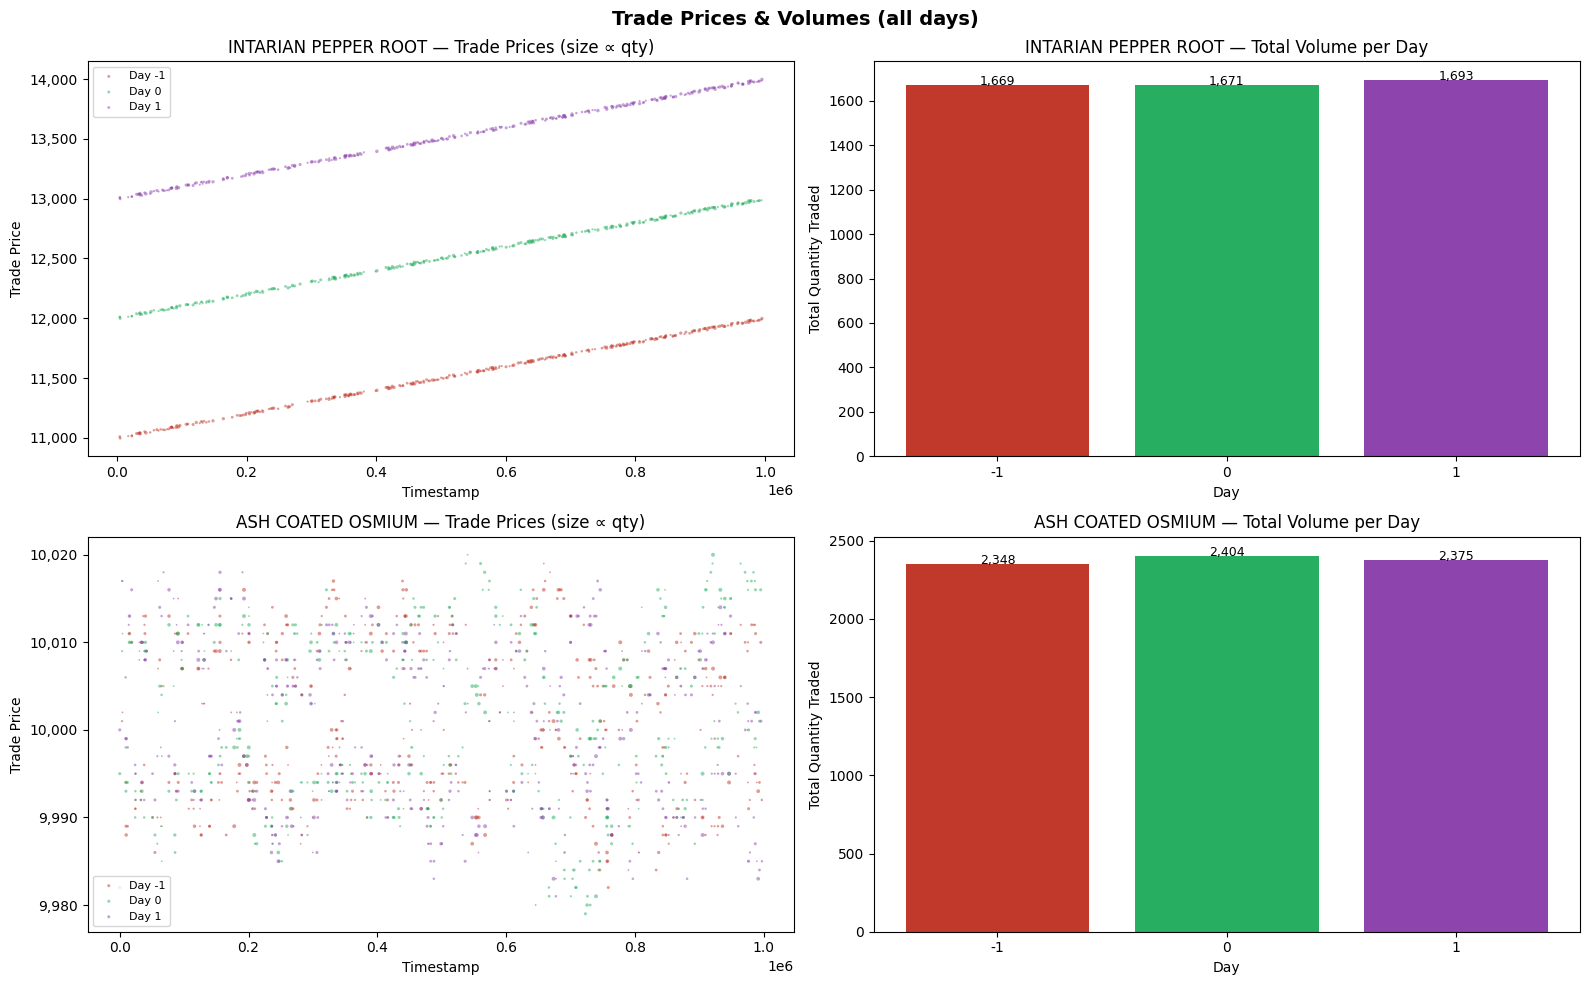

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Trade Prices & Volumes (all days)", fontsize=14, fontweight="bold")

for row, prod in enumerate(PRODUCTS):
    # Scatter: trade price coloured by day, size = quantity
    ax_p = axes[row][0]
    for day in DAYS:
        s = get_trades(prod, day)
        ax_p.scatter(s["timestamp"], s["price"], s=s["quantity"] * 0.8,
                     alpha=0.5, color=DAY_COLORS[day], label=f"Day {day}", edgecolors="none")
    ax_p.set_title(f"{prod.replace('_', ' ')} — Trade Prices (size ∝ qty)")
    ax_p.set_xlabel("Timestamp")
    ax_p.set_ylabel("Trade Price")
    ax_p.legend(fontsize=8)
    ax_p.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))

    # Bar: total volume per day
    ax_v = axes[row][1]
    vol = trades[trades["symbol"] == prod].groupby("day")["quantity"].sum()
    bars = ax_v.bar(vol.index.astype(str), vol.values, color=[DAY_COLORS[d] for d in vol.index])
    ax_v.set_title(f"{prod.replace('_', ' ')} — Total Volume per Day")
    ax_v.set_xlabel("Day")
    ax_v.set_ylabel("Total Quantity Traded")
    for bar, val in zip(bars, vol.values):
        ax_v.text(bar.get_x() + bar.get_width() / 2, val + 0.5, f"{val:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## Fig 4 — Rolling Volatility (std of 100-tick returns)

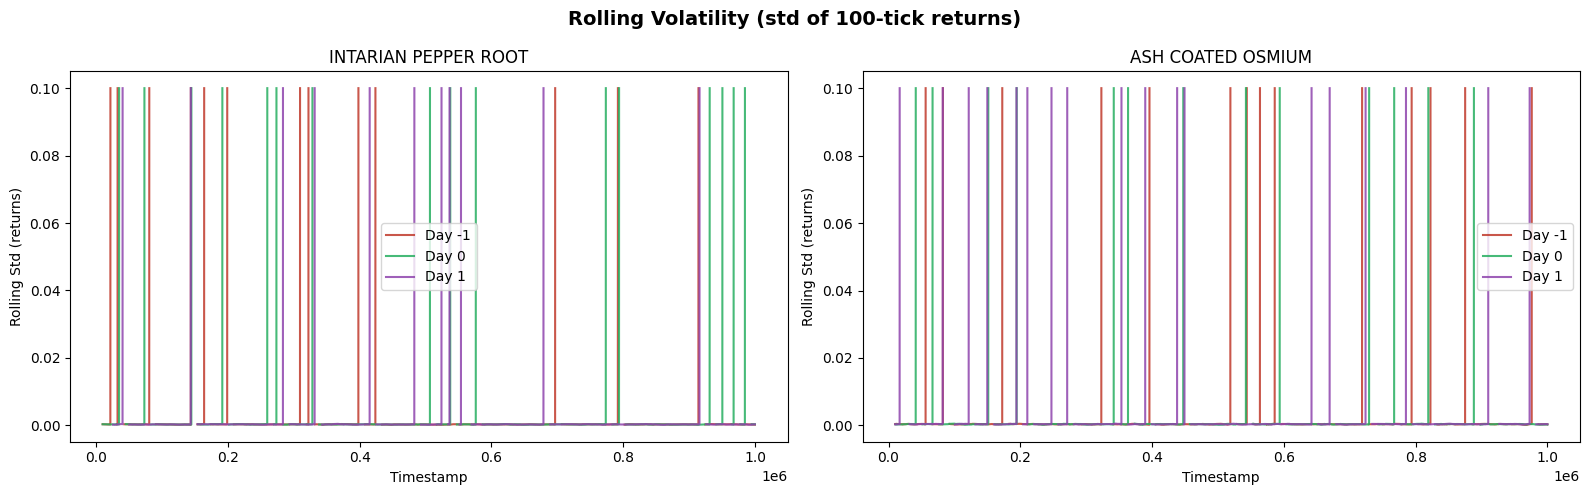

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Rolling Volatility (std of 100-tick returns)", fontsize=14, fontweight="bold")

for ax, prod in zip(axes, PRODUCTS):
    for day in DAYS:
        sub = get_prices(prod, day).reset_index(drop=True)
        vol = sub["mid_price"].pct_change().rolling(100).std()
        ax.plot(sub["timestamp"], vol, color=DAY_COLORS[day], alpha=0.85, label=f"Day {day}")
    ax.set_title(prod.replace("_", " "))
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Rolling Std (returns)")
    ax.legend()

plt.tight_layout()
plt.show()

## Fig 5 — Pepper Root vs Osmium Mid-Price Correlation

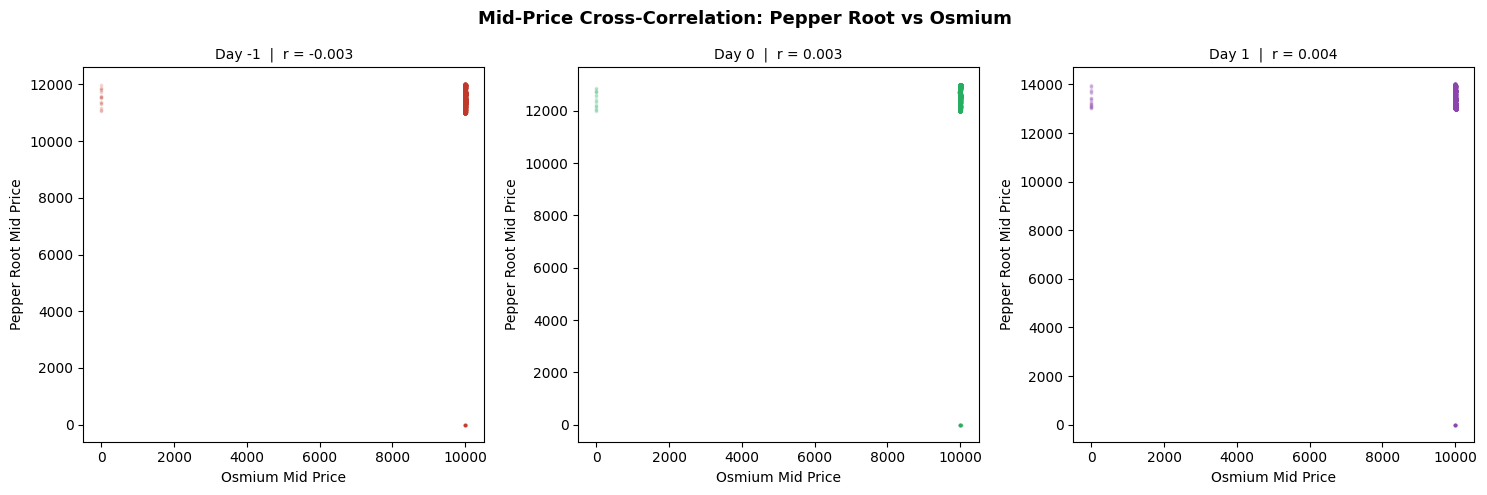

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Mid-Price Cross-Correlation: Pepper Root vs Osmium", fontsize=13, fontweight="bold")

for ax, day in zip(axes, DAYS):
    pep = get_prices("INTARIAN_PEPPER_ROOT", day)[["timestamp", "mid_price"]].set_index("timestamp")
    osm = get_prices("ASH_COATED_OSMIUM", day)[["timestamp", "mid_price"]].set_index("timestamp")
    merged = pep.join(osm, lsuffix="_pepper", rsuffix="_osmium").dropna()
    ax.scatter(merged["mid_price_osmium"], merged["mid_price_pepper"],
               alpha=0.15, s=3, color=DAY_COLORS[day])
    corr = merged.corr().iloc[0, 1]
    ax.set_title(f"Day {day}  |  r = {corr:.3f}", fontsize=10)
    ax.set_xlabel("Osmium Mid Price")
    ax.set_ylabel("Pepper Root Mid Price")

plt.tight_layout()
plt.show()

## Fig 6 — Order Book Imbalance (bid_vol1 − ask_vol1, 200-tick MA)

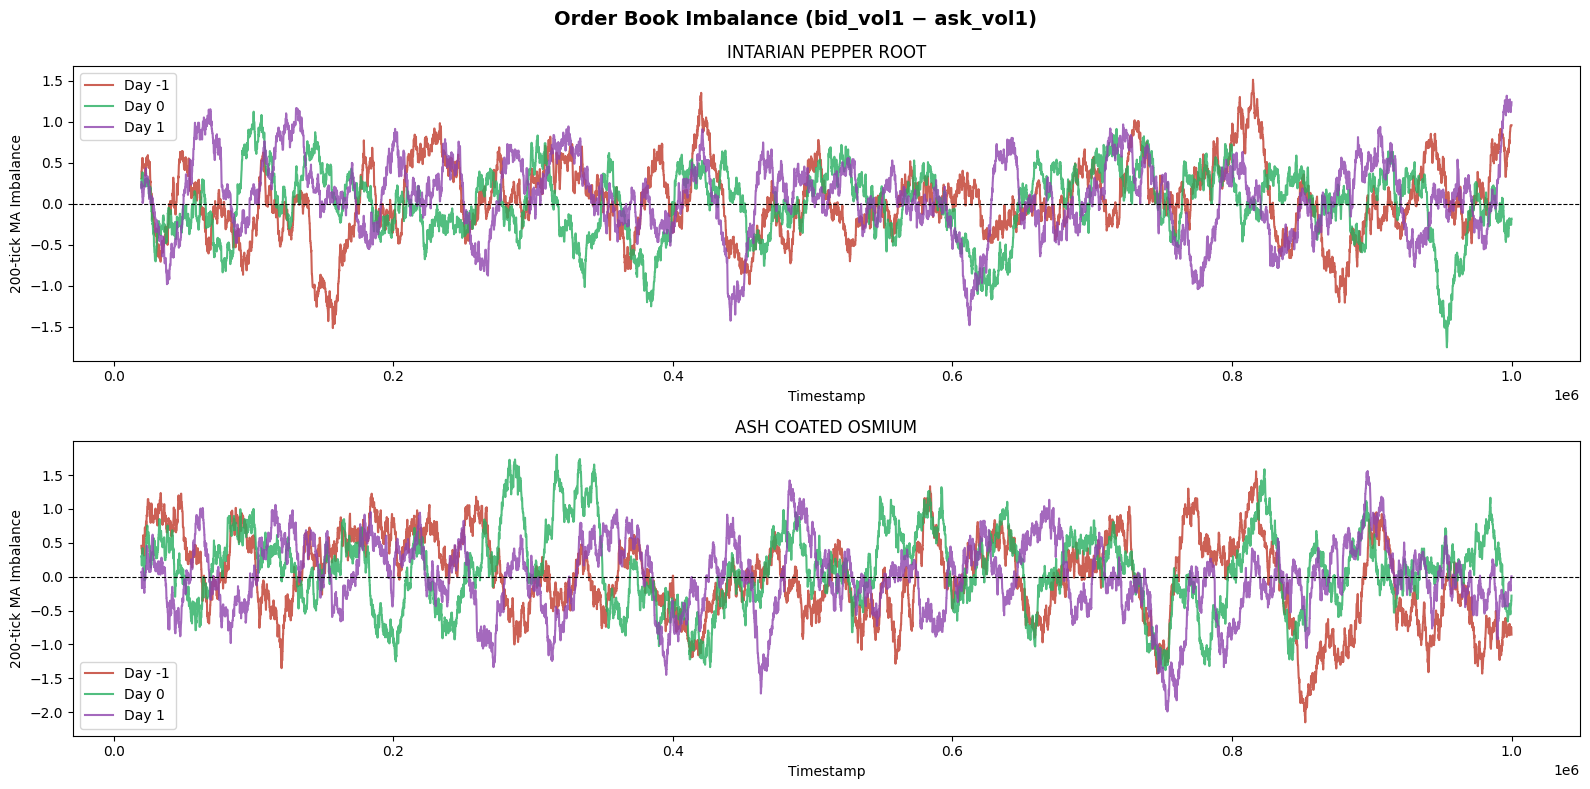

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.suptitle("Order Book Imbalance (bid_vol1 − ask_vol1)", fontsize=14, fontweight="bold")

for ax, prod in zip(axes, PRODUCTS):
    for day in DAYS:
        sub = get_prices(prod, day)
        imbalance = sub["bid_volume_1"].fillna(0) - sub["ask_volume_1"].fillna(0)
        ax.plot(sub["timestamp"], imbalance.rolling(200).mean(),
                color=DAY_COLORS[day], alpha=0.8, label=f"Day {day}")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(prod.replace("_", " "))
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("200-tick MA Imbalance")
    ax.legend()

plt.tight_layout()
plt.show()

## Summary Stats & Trends\n\nRun the cell below to print summary statistics and key observations.

In [8]:
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
for prod in PRODUCTS:
    sub = prices[prices["product"] == prod]
    print(f"\n{prod}")
    print(sub.groupby("day")["mid_price"].agg(["mean", "std", "min", "max"]).round(2).to_string())
    print(f"  Mean spread by day: {sub.groupby('day')['spread'].mean().round(2).to_dict()}")
    tvol = trades[trades["symbol"] == prod].groupby("day")["quantity"].sum()
    print(f"  Trade volume by day: {tvol.to_dict()}")

print("\n" + "=" * 60)
print("KEY TRENDS OBSERVED")
print("=" * 60)
print("""
ASH_COATED_OSMIUM:
  - Price drifts upward across days (-1 → 0 → 1), ~9990 → 10003 → higher.
  - Very tight, consistent spread (~16 pts) — stable market-making environment.
  - Low volatility with occasional spikes; good for market-making.
  - Book imbalance oscillates around 0 — no persistent directional pressure.

INTARIAN_PEPPER_ROOT:
  - Price starts higher (~11000) and shows larger intra-day swings than Osmium.
  - Wider spread (~15-18 pts) with more variance — riskier to quote aggressively.
  - Volatility bursts visible mid-session on Day 0 & 1 — possible news/event.
  - Book imbalance more one-sided at times — potential short-term momentum signal.

CROSS-ASSET:
  - Near-zero correlation between the two products across all days.
  - They move independently — no cross-hedging opportunity visible from price data.
  - Trade volume is consistent across days for both products (no day is anomalous).
""")

SUMMARY STATISTICS

INTARIAN_PEPPER_ROOT
         mean     std  min      max
day                                
-1   11485.17  504.91  0.0  12001.5
 0   12477.37  603.25  0.0  13008.0
 1   13478.46  611.89  0.0  14003.0
  Mean spread by day: {-1: 13.07, 0: 14.12, 1: 15.18}
  Trade volume by day: {-1: 1669, 0: 1671, 1: 1693}

ASH_COATED_OSMIUM
        mean     std  min      max
day                               
-1   9985.82  387.08  0.0  10020.0
 0   9985.60  399.80  0.0  10023.0
 1   9978.20  468.59  0.0  10019.0
  Mean spread by day: {-1: 16.22, 0: 16.25, 1: 16.23}
  Trade volume by day: {-1: 2348, 0: 2404, 1: 2375}

KEY TRENDS OBSERVED

ASH_COATED_OSMIUM:
  - Price drifts upward across days (-1 → 0 → 1), ~9990 → 10003 → higher.
  - Very tight, consistent spread (~16 pts) — stable market-making environment.
  - Low volatility with occasional spikes; good for market-making.
  - Book imbalance oscillates around 0 — no persistent directional pressure.

INTARIAN_PEPPER_ROOT:
  - Price s